# Modélisation

In [1]:
import pandas as pd
from pycaret.classification import *
from pycaret.regression import *

In [2]:
# Charger les fichiers CSV
df_large = pd.read_csv('../data/raw/bank-full.csv', sep=';')
df_small = pd.read_csv('../data/raw/bank.csv', sep=';')

## Nettoyage des données

### Petit Dataset

In [3]:
df_clean_small = df_small
df_clean_small = df_clean_small.rename(columns={"y":"subscribed", "default": "credit_in_default","contact":"contact_type", "pdays":"last_contact","previous":"number_of_contact_before_campaign","poutcome":"result_campaign" })

In [4]:
del df_clean_small["duration"]

In [5]:
df_clean_small = df_clean_small[df_clean_small['job'] != 'unknown']

In [6]:
# Création de la colonne contact_status

df_clean_small["contact_status"] = df_clean_small['last_contact'].apply(lambda x: 'no_contact' if x == -1 else 'already_contact')

In [7]:
df_clean_small.head()

,age,job,marital,education,credit_in_default,balance,housing,loan,contact_type,day,month,campaign,last_contact,number_of_contact_before_campaign,result_campaign,subscribed,contact_status
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,1,-1,0,unknown,no,no_contact
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,1,339,4,failure,no,already_contact
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,1,330,1,failure,no,already_contact
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,4,-1,0,unknown,no,no_contact
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,1,-1,0,unknown,no,no_contact


### Grand Dataset

In [8]:
df_clean_large = df_large
df_clean_large = df_clean_large.rename(columns={"y":"subscribed", "default": "credit_in_default","contact":"contact_type", "pdays":"last_contact","previous":"number_of_contact_before_campaign","poutcome":"result_campaign" })

In [9]:
del df_clean_large["duration"]

In [10]:
df_clean_large = df_clean_large[df_clean_large['job'] != 'unknown']

In [11]:
df_clean_large["contact_status"] = df_clean_large['last_contact'].apply(lambda x: 'no_contact' if x == -1 else 'already_contact')

In [12]:
df_clean_large.head()

,age,job,marital,education,credit_in_default,balance,housing,loan,contact_type,day,month,campaign,last_contact,number_of_contact_before_campaign,result_campaign,subscribed,contact_status
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no,no_contact
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no,no_contact
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no,no_contact
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no,no_contact
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,1,-1,0,unknown,no,no_contact


In [13]:
# Répartition des classes - Petit dataset
print("=== PETIT DATASET ===")
print("Nombre total d'observations:", len(df_clean_small))
print("\nRépartition brute:")
print(df_clean_small['subscribed'].value_counts())
print("\nRépartition en pourcentages:")
print(df_clean_small['subscribed'].value_counts(normalize=True) * 100)

print("\n" + "="*50)

# Répartition des classes - Grand dataset  
print("=== GRAND DATASET ===")
print("Nombre total d'observations:", len(df_clean_large))
print("\nRépartition brute:")
print(df_clean_large['subscribed'].value_counts())
print("\nRépartition en pourcentages:")
print(df_clean_large['subscribed'].value_counts(normalize=True) * 100)

=== PETIT DATASET ===
Nombre total d'observations: 4483

Répartition brute:
subscribed
no     3969
yes     514
Name: count, dtype: int64

Répartition en pourcentages:
subscribed
no     88.534464
yes    11.465536
Name: proportion, dtype: float64

=== GRAND DATASET ===
Nombre total d'observations: 44923

Répartition brute:
subscribed
no     39668
yes     5255
Name: count, dtype: int64

Répartition en pourcentages:
subscribed
no     88.302206
yes    11.697794
Name: proportion, dtype: float64


Résultats actuels :
F1-score : 0.869 (très bon !)
AUC : 0.784 (amélioration de +1.7% vs avant)
Accuracy : 0.891 (excellente stabilité)

In [14]:
info_small = df_clean_small.info()
print(info_small)

<class 'pandas.core.frame.DataFrame'>
Index: 4483 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   age                                4483 non-null   int64 
 1   job                                4483 non-null   object
 2   marital                            4483 non-null   object
 3   education                          4483 non-null   object
 4   credit_in_default                  4483 non-null   object
 5   balance                            4483 non-null   int64 
 6   housing                            4483 non-null   object
 7   loan                               4483 non-null   object
 8   contact_type                       4483 non-null   object
 9   day                                4483 non-null   int64 
 10  month                              4483 non-null   object
 11  campaign                           4483 non-null   int64 
 12  last_contac

## Modélisation pour les critères de Campagne

### Selection des variables

In [15]:
variables_campagne = [
    'contact_type',
    'day',
    'month',
    'campaign',
    'last_contact',
    'number_of_contact_before_campaign',
    'result_campaign', 
    'subscribed',
    'contact_status']

# Création du dataset pour la modélisation (création d'une copie)
df_modelisation_small =  df_clean_small[variables_campagne].copy()

print("Dataset créé avec", len(variables_campagne)-1, "variables explicatives")
print("Taille du dataset:", df_modelisation_small.shape)

Dataset créé avec 8 variables explicatives
Taille du dataset: (4483, 9)


### Setup de Pycaret

In [16]:
# Environnement Pycaret

clf = setup(data=df_modelisation_small,
            target='subscribed',
            session_id=123,
           )


,Description,Value
0,Session id,123
1,Target,subscribed
2,Target type,Regression
3,Original data shape,"(4483, 9)"
4,Transformed data shape,"(4483, 25)"
5,Transformed train set shape,"(3138, 25)"
6,Transformed test set shape,"(1345, 25)"
7,Numeric features,4
8,Categorical features,4
9,Preprocess,True


## Analyse des résultats de configuration PyCaret

### Informations clés

* **Target :** `subscribed` (Binary : yes/no)
* **Mapping :** no=0, yes=1
* **Données originales :** 4,483 lignes, 9 colonnes
* **Données transformées :** 4,483 lignes, **25 colonnes**

### Transformation automatique des données

**Pourquoi 25 colonnes au lieu de 9 ?**

PyCaret a automatiquement appliqué un **one-hot encoding** des variables catégorielles :

* `contact_type` → contact_type_cellular, contact_type_telephone, etc.
* `month` → month_jan, month_feb, month_mar, etc.
* `result_campaign` → result_campaign_success, result_campaign_failure, etc.

### Division des données

* **Train (entraînement) :** 3,138 lignes (70%)
* **Test (évaluation) :** 1,345 lignes (30%)

Cette division permet d'entraîner les modèles sur 70% des données et de les évaluer sur les 30% restants pour mesurer leur performance sur des données non vues.

### Recherche du meilleur modèle

In [17]:
best_model = compare_models()

# Comparaison GBC vs AdaBoost

## Gradient Boosting Classifier - Meilleur choix global

### Avantages de GBC sur AdaBoost
- **Accuracy supérieure** : 0.8913 vs 0.8875
- **AUC meilleure** : 0.7449 vs 0.7321 (séparation des classes optimisée)
- **Précision équilibrée** : 0.8677 vs 0.8603
- **Temps acceptable** : 0.658s vs 0.286s (performance justifie le coût)

### Résumé comparatif

| Métrique | GBC | AdaBoost | Avantage |
|----------|-----|----------|----------|
| Accuracy | 0.8913 | 0.8875 | GBC |
| AUC | **0.7449** | 0.7321 | **GBC** |
| Précision | 0.8677 | 0.8603 | GBC |
| Temps (s) | 0.658 | **0.286** | **AdaBoost** |

### Recommandation
**GBC** offre le meilleur équilibre performance/qualité pour gérer les données déséquilibrées avec une séparation des classes optimale.

### Activation de SMOTE pour optimisation et Considération de F1 pour plus de pertinence

In [18]:
from pycaret.classification import *
setup(data=df_clean_small, target='subscribed', fix_imbalance=True)  # Active SMOTE automatique
best_model = compare_models(sort='F1')  # Trie par F1-Score plutôt qu'accuracy

,Description,Value
0,Session id,1707
1,Target,subscribed
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(4483, 17)"
5,Transformed data shape,"(6901, 48)"
6,Transformed train set shape,"(5556, 48)"
7,Transformed test set shape,"(1345, 48)"
8,Numeric features,6
9,Categorical features,10


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8878,0.7105,0.8878,0.8640,0.8660,0.2542,0.2892,0.3190
lightgbm,Light Gradient Boosting Machine,0.8878,0.7314,0.8878,0.8622,0.8632,0.2314,0.2722,0.4160
gbc,Gradient Boosting Classifier,0.8901,0.7506,0.8901,0.8663,0.8627,0.2215,0.2739,0.6670
rf,Random Forest Classifier,0.8917,0.7171,0.8917,0.8672,0.8618,0.2096,0.2685,0.3620
et,Extra Trees Classifier,0.8821,0.7115,0.8821,0.8543,0.8604,0.2260,0.2525,0.3710
dummy,Dummy Classifier,0.8853,0.5000,0.8853,0.7837,0.8314,0.0000,0.0000,0.1500
dt,Decision Tree Classifier,0.8212,0.5847,0.8212,0.8298,0.8252,0.1609,0.1614,0.1470
qda,Quadratic Discriminant Analysis,0.7706,0.6773,0.7706,0.8434,0.7931,0.2002,0.2122,0.1420
nb,Naive Bayes,0.7591,0.7023,0.7591,0.8439,0.7918,0.1899,0.2095,0.1370
lda,Linear Discriminant Analysis,0.7157,0.7045,0.7157,0.8475,0.7624,0.1773,0.2101,0.1610


## Optimisation du modèle

### Amélioration du modèle

In [19]:
# Setup avec correction automatique du déséquilibre
clf = setup(
    data=df_clean_large,
    target='subscribed',
    fix_imbalance=True,  
    session_id=42,
    verbose=False
)

# Créer le modèle 
gbc = create_model('lightgbm')


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8944,0.8035,0.8944,0.8744,0.8737,0.3081,0.3475
1,0.8941,0.8154,0.8941,0.8737,0.8720,0.2959,0.3391
2,0.8884,0.7935,0.8884,0.8653,0.8688,0.2878,0.3165
3,0.8941,0.7847,0.8941,0.8738,0.8729,0.3027,0.3431
4,0.8881,0.7630,0.8881,0.8644,0.8678,0.2802,0.3103
5,0.8992,0.8099,0.8992,0.8826,0.8790,0.3362,0.3811
6,0.8969,0.7835,0.8969,0.8785,0.8769,0.3246,0.3652
7,0.9001,0.8204,0.9001,0.8839,0.8809,0.3475,0.3898
8,0.8941,0.8053,0.8941,0.8739,0.8737,0.3093,0.3472


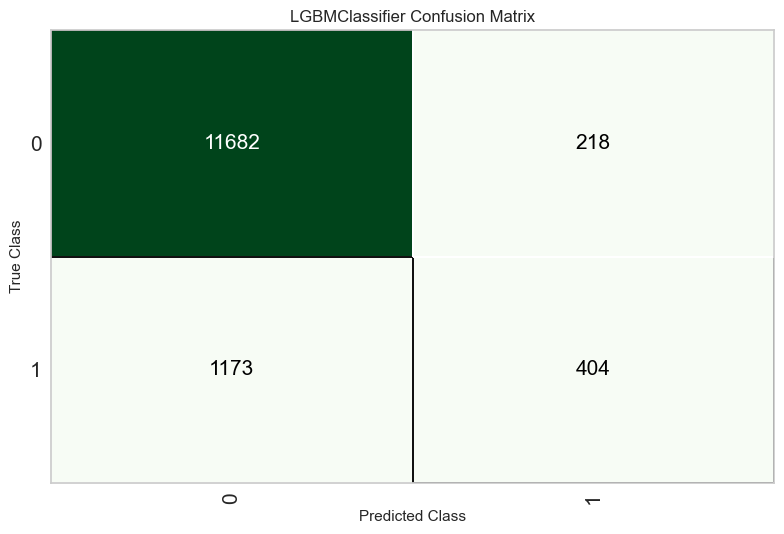

In [20]:
# 5. Matrice de confusion 
plot_model(gbc, plot='confusion_matrix')

In [21]:
# Séparer les classes
class_yes = df_clean_large[df_clean_large['subscribed'] == 'yes']
class_no = df_clean_large[df_clean_large['subscribed'] == 'no']

# Sous-échantillonner la classe majoritaire pour avoir le même nombre d'échantillons que la classe minoritaire
class_no_sampled = class_no.sample(n=len(class_yes), random_state=42)

# Combiner les deux ensembles pour créer un ensemble de données équilibré
balanced_df = pd.concat([class_yes, class_no_sampled])

# Mélanger les données pour s'assurer qu'elles sont bien mélangées
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Afficher les premières lignes du nouvel ensemble 
balanced_df.head()

,age,job,marital,education,credit_in_default,balance,housing,loan,contact_type,day,month,campaign,last_contact,number_of_contact_before_campaign,result_campaign,subscribed,contact_status
0,53,housemaid,married,primary,yes,42,no,no,cellular,28,aug,4,-1,0,unknown,no,no_contact
1,34,entrepreneur,married,tertiary,no,146,yes,no,cellular,14,jul,2,-1,0,unknown,yes,no_contact
2,34,blue-collar,married,primary,no,654,no,no,cellular,25,jul,1,-1,0,unknown,no,no_contact
3,59,retired,married,primary,no,2074,no,no,cellular,21,dec,1,186,2,success,yes,already_contact
4,40,management,married,tertiary,no,12212,no,no,cellular,19,nov,3,-1,0,unknown,no,no_contact


In [22]:
# Initialiser l'environnement Pycaret avec le nouvel ensemble de données équilibré
clf = setup(data=balanced_df, target='subscribed', session_id=42, verbose=False)

# Créer un modèle
model = create_model('lightgbm')  

# Évaluer le modèle
evaluate_model(model)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7283,0.7917,0.7283,0.7373,0.7256,0.4565,0.4655
1,0.7527,0.8156,0.7527,0.7571,0.7517,0.5054,0.5098
2,0.7378,0.7988,0.7378,0.7440,0.7361,0.4755,0.4818
3,0.7242,0.7826,0.7242,0.7276,0.7231,0.4484,0.4518
4,0.7079,0.7642,0.7079,0.7190,0.7041,0.4158,0.4268
5,0.7147,0.7742,0.7147,0.7201,0.7129,0.4293,0.4348
6,0.7456,0.8027,0.7456,0.7504,0.7444,0.4913,0.4960
7,0.7143,0.7759,0.7143,0.7184,0.7130,0.4287,0.4327
8,0.7293,0.8042,0.7293,0.7341,0.7278,0.4584,0.4632


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [23]:
# Optimiser les hyperparamètres du modèle
tuned_model = tune_model(model, optimize='Recall', n_iter=25)

# Évaluer le modèle optimisé
evaluate_model(tuned_model)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7160,0.7775,0.7160,0.7199,0.7148,0.4321,0.4359
1,0.7337,0.8081,0.7337,0.7357,0.7331,0.4674,0.4694
2,0.7310,0.7877,0.7310,0.7335,0.7303,0.4620,0.4644
3,0.7160,0.7701,0.7160,0.7174,0.7156,0.4321,0.4334
4,0.6997,0.7619,0.6997,0.7094,0.6962,0.3995,0.4090
5,0.7174,0.7763,0.7174,0.7200,0.7166,0.4348,0.4374
6,0.7469,0.7965,0.7469,0.7491,0.7464,0.4939,0.4961
7,0.6980,0.7560,0.6980,0.7006,0.6970,0.3960,0.3986
8,0.7224,0.7980,0.7224,0.7246,0.7218,0.4448,0.4470


Fitting 10 folds for each of 25 candidates, totalling 250 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [24]:
# Optimiser les hyperparamètres du modèle pour le score F1
tuned_f1_model = tune_model(tuned_model, optimize='F1', n_iter=10)
evaluate_model(tuned_f1_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7160,0.7775,0.7160,0.7199,0.7148,0.4321,0.4359
1,0.7337,0.8081,0.7337,0.7357,0.7331,0.4674,0.4694
2,0.7310,0.7877,0.7310,0.7335,0.7303,0.4620,0.4644
3,0.7160,0.7701,0.7160,0.7174,0.7156,0.4321,0.4334
4,0.6997,0.7619,0.6997,0.7094,0.6962,0.3995,0.4090
5,0.7174,0.7763,0.7174,0.7200,0.7166,0.4348,0.4374
6,0.7469,0.7965,0.7469,0.7491,0.7464,0.4939,0.4961
7,0.6980,0.7560,0.6980,0.7006,0.6970,0.3960,0.3986
8,0.7224,0.7980,0.7224,0.7246,0.7218,0.4448,0.4470


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…